In [3]:
from google.colab import files

uploaded = files.upload()

Saving agriculture_yield_dataset.csv to agriculture_yield_dataset.csv


In [5]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

df = pd.read_csv('agriculture_yield_dataset.csv')



In [6]:
# Q1. Dataset Overview
overview = pd.DataFrame({
    'Metric': ['Rows', 'Columns'],
    'Value': [df.shape[0], df.shape[1]]
})
display(overview)

columns_df = pd.DataFrame({
    'Column Names': df.columns
})
display(columns_df)

display(df.head(10))


,Metric,Value
0,Rows,1500
1,Columns,8


,Column Names
0,rainfall_mm
1,temperature_c
2,fertilizer_kg
3,irrigation_hours
4,soil_ph
5,crop_type
6,soil_type
7,yield_ton_per_hectare


,rainfall_mm,temperature_c,fertilizer_kg,irrigation_hours,soil_ph,crop_type,soil_type,yield_ton_per_hectare
0,588.6,18.6,242.4,6.5,6.5,Maize,Loamy,5.92
1,772.8,34.6,247.2,10.0,6.5,Maize,Sandy,6.24
2,970.9,36.3,168.4,7.3,6.4,Wheat,Sandy,4.77
3,611.7,19.0,121.7,3.7,6.0,Maize,Loamy,4.04
4,696.1,29.6,184.6,5.1,6.1,Cotton,Clay,5.17
5,831.9,28.0,190.3,2.1,6.1,Soybean,Loamy,5.50
6,1023.8,32.0,108.5,6.9,6.2,Cotton,Loamy,5.44
7,1142.4,18.4,241.9,4.1,7.3,Soybean,Sandy,5.88
8,810.4,36.4,164.8,9.9,6.5,Wheat,Loamy,6.35
9,1085.5,29.4,89.3,8.3,5.8,Cotton,Loamy,6.30


In [7]:
# Q2. Data Types and Missing Values
info_df = pd.DataFrame({
    'Column Name': df.columns,
    'Data Type': df.dtypes.values,
    'Missing Values': df.isnull().sum().values
})
display(info_df)


,Column Name,Data Type,Missing Values
0,rainfall_mm,float64,0
1,temperature_c,float64,0
2,fertilizer_kg,float64,0
3,irrigation_hours,float64,0
4,soil_ph,float64,0
5,crop_type,object,0
6,soil_type,object,0
7,yield_ton_per_hectare,float64,0


In [8]:
# Q3. Descriptive Statistics
stats_df = df.describe().T
display(stats_df)


,count,mean,std,min,25%,50%,75%,max
rainfall_mm,1500.0,754.054667,255.097216,300.20,536.1750,761.20,964.375,1200.00
temperature_c,1500.0,27.749467,5.758101,18.00,22.6000,27.70,32.600,38.00
fertilizer_kg,1500.0,148.744067,56.990279,50.30,98.6000,146.85,196.575,249.90
irrigation_hours,1500.0,5.403267,2.584329,1.00,3.2000,5.40,7.600,10.00
soil_ph,1500.0,6.759133,0.719742,5.50,6.1000,6.80,7.400,8.00
yield_ton_per_hectare,1500.0,5.028793,0.968282,2.09,4.3375,5.01,5.740,7.86


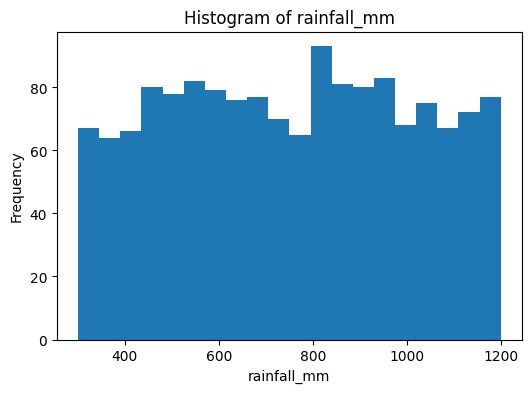

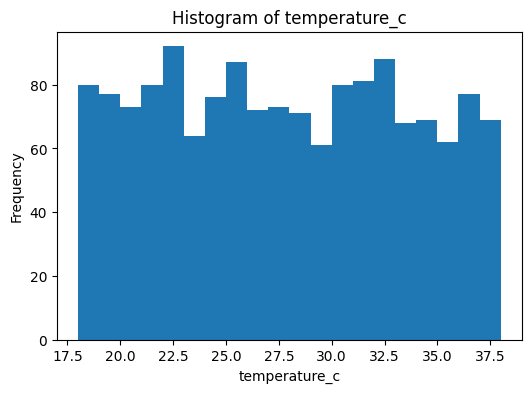

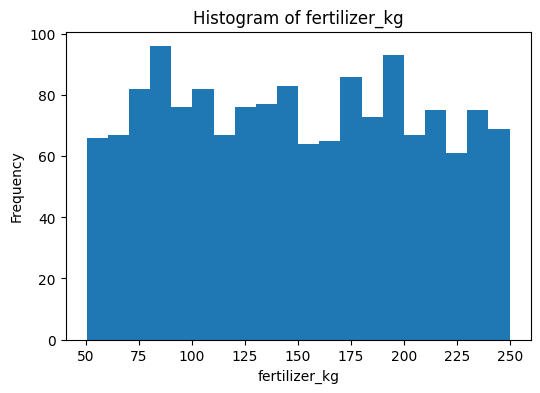

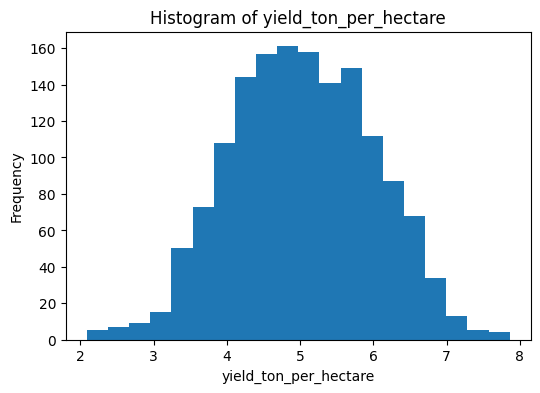

In [9]:
# Q4. Distribution Analysis
columns = [
    'rainfall_mm',
    'temperature_c',
    'fertilizer_kg',
    'yield_ton_per_hectare'
]
for col in columns:
    plt.figure(figsize=(6, 4))
    plt.hist(df[col], bins=20)
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

,Crop Type,Count
0,Cotton,311
1,Soybean,306
2,Wheat,303
3,Rice,293
4,Maize,287


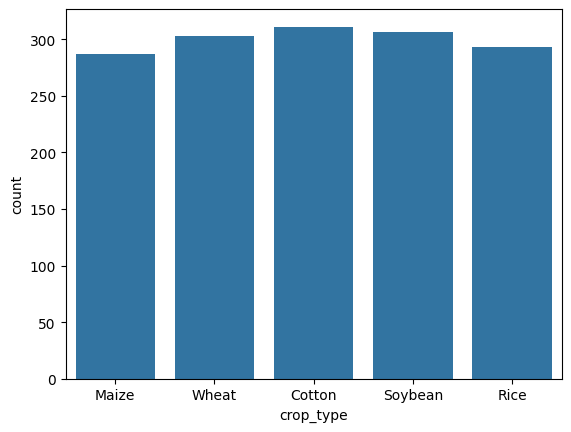

In [10]:
# Q5. Crop Type Analysis
crop_count = df['crop_type'].value_counts().reset_index()
crop_count.columns = ['Crop Type', 'Count']
display(crop_count)

sns.countplot(x='crop_type', data=df)
plt.show()


,Soil Type,Count
0,Clay,534
1,Sandy,492
2,Loamy,474


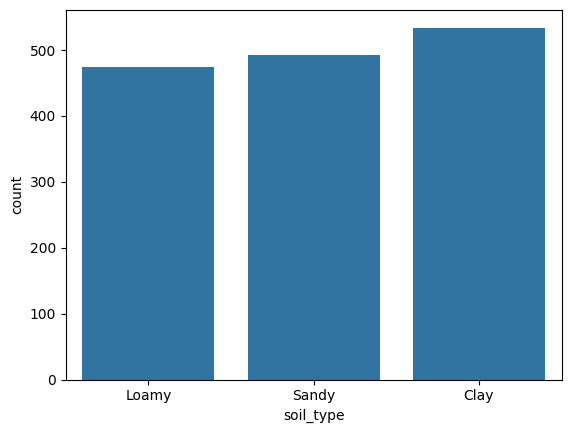

In [11]:
# Q6. Soil Type Analysis
soil_count = df['soil_type'].value_counts().reset_index()
soil_count.columns = ['Soil Type', 'Count']
display(soil_count)

sns.countplot(x='soil_type', data=df)
plt.show()


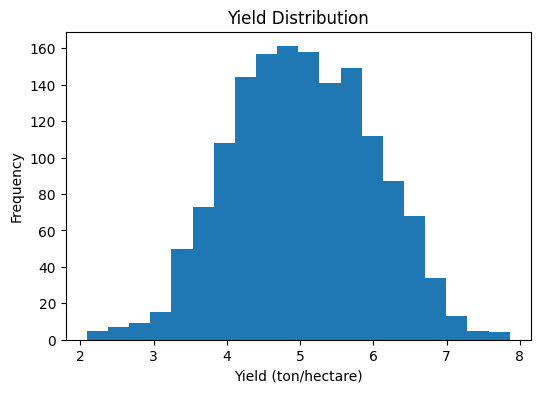

In [12]:
# Q7. Yield Distribution
plt.figure(figsize=(6, 4))
plt.hist(df['yield_ton_per_hectare'], bins=20)
plt.title('Yield Distribution')
plt.xlabel('Yield (ton/hectare)')
plt.ylabel('Frequency')
plt.show()


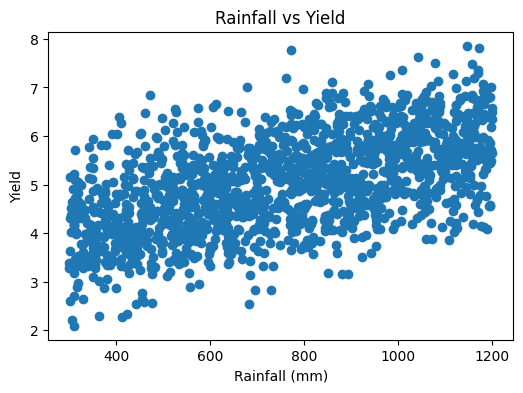

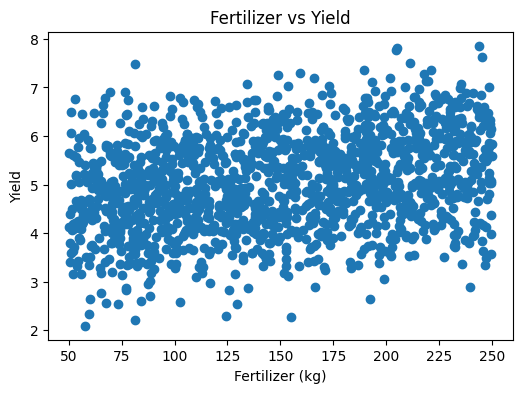

In [13]:
# Q8. Scatter Plot Analysis
plt.figure(figsize=(6, 4))
plt.scatter(df['rainfall_mm'], df['yield_ton_per_hectare'])
plt.xlabel('Rainfall (mm)')
plt.ylabel('Yield')
plt.title('Rainfall vs Yield')
plt.show()

plt.figure(figsize=(6, 4))
plt.scatter(df['fertilizer_kg'], df['yield_ton_per_hectare'])
plt.xlabel('Fertilizer (kg)')
plt.ylabel('Yield')
plt.title('Fertilizer vs Yield')
plt.show()


,rainfall_mm,temperature_c,fertilizer_kg,irrigation_hours,soil_ph,yield_ton_per_hectare
rainfall_mm,1.000000,0.026721,0.002558,0.010877,0.006916,0.553704
temperature_c,0.026721,1.000000,0.037468,0.007114,0.001513,-0.022559
fertilizer_kg,0.002558,0.037468,1.000000,-0.010497,0.010001,0.278043
irrigation_hours,0.010877,0.007114,-0.010497,1.000000,0.009307,0.542664
soil_ph,0.006916,0.001513,0.010001,0.009307,1.000000,0.024412
yield_ton_per_hectare,0.553704,-0.022559,0.278043,0.542664,0.024412,1.000000


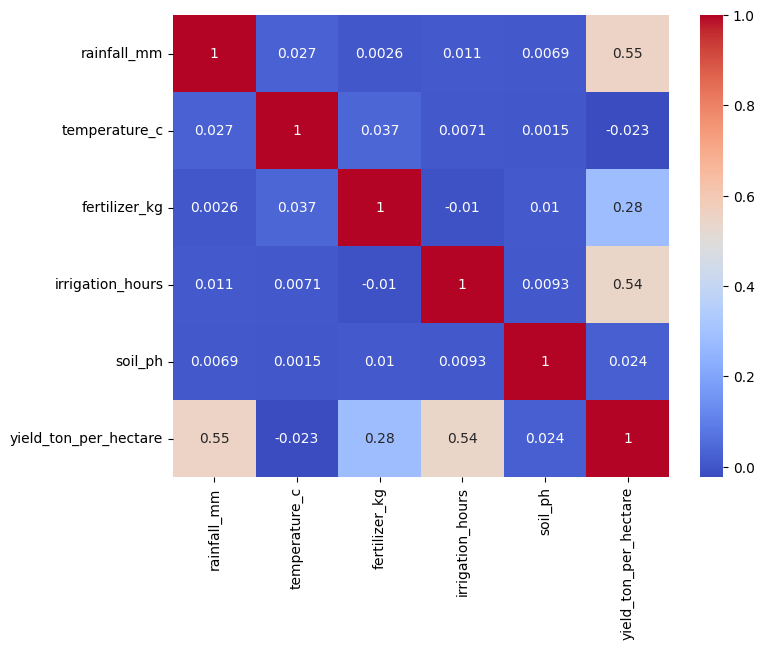

In [14]:
# Q9. Correlation Analysis
corr = df.select_dtypes(include=np.number).corr()
display(corr)

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()


In [15]:
# Q10. Group-Based Analysis
crop_yield = df.groupby('crop_type')['yield_ton_per_hectare'].mean().reset_index()
crop_yield.columns = ['Crop Type', 'Average Yield']
display(crop_yield)

soil_yield = df.groupby('soil_type')['yield_ton_per_hectare'].mean().reset_index()
soil_yield.columns = ['Soil Type', 'Average Yield']
display(soil_yield)



,Crop Type,Average Yield
0,Cotton,4.607299
1,Maize,4.897143
2,Rice,5.494744
3,Soybean,5.173431
4,Wheat,4.989472


,Soil Type,Average Yield
0,Clay,5.134326
1,Loamy,5.366519
2,Sandy,4.588882


In [16]:
# Q11. Feature Encoding
df_encoded = pd.get_dummies(
    df,
    columns=['crop_type', 'soil_type']
)
display(df_encoded.head())


,rainfall_mm,temperature_c,fertilizer_kg,irrigation_hours,soil_ph,yield_ton_per_hectare,crop_type_Cotton,crop_type_Maize,crop_type_Rice,crop_type_Soybean,crop_type_Wheat,soil_type_Clay,soil_type_Loamy,soil_type_Sandy
0,588.6,18.6,242.4,6.5,6.5,5.92,False,True,False,False,False,False,True,False
1,772.8,34.6,247.2,10.0,6.5,6.24,False,True,False,False,False,False,False,True
2,970.9,36.3,168.4,7.3,6.4,4.77,False,False,False,False,True,False,False,True
3,611.7,19.0,121.7,3.7,6.0,4.04,False,True,False,False,False,False,True,False
4,696.1,29.6,184.6,5.1,6.1,5.17,True,False,False,False,False,True,False,False


In [17]:
# Q12. Feature Selection
X = df_encoded.drop('yield_ton_per_hectare', axis=1)
y = df_encoded['yield_ton_per_hectare']

display(pd.DataFrame({'Input Features': X.columns}))
display(pd.DataFrame({'Target Variable': ['yield_ton_per_hectare']}))


,Input Features
0,rainfall_mm
1,temperature_c
2,fertilizer_kg
3,irrigation_hours
4,soil_ph
5,crop_type_Cotton
6,crop_type_Maize
7,crop_type_Rice
8,crop_type_Soybean
9,crop_type_Wheat


,Target Variable
0,yield_ton_per_hectare


In [18]:
# Q13. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

split_df = pd.DataFrame({
    'Dataset': ['X_train', 'X_test', 'y_train', 'y_test'],
    'Shape': [
        X_train.shape,
        X_test.shape,
        y_train.shape,
        y_test.shape
    ]
})
display(split_df)


,Dataset,Shape
0,X_train,"(1200, 13)"
1,X_test,"(300, 13)"
2,y_train,"(1200,)"
3,y_test,"(300,)"


In [19]:
# Q14. Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
}).sort_values(by='Coefficient', ascending=False)

display(coef_df)

display(pd.DataFrame({
    'Intercept': [model.intercept_]
}))

,Feature,Coefficient
7,crop_type_Rice,0.477369
11,soil_type_Loamy,0.365627
3,irrigation_hours,0.198327
8,crop_type_Soybean,0.095096
10,soil_type_Clay,0.062653
2,fertilizer_kg,0.004978
4,soil_ph,0.004901
0,rainfall_mm,0.002035
1,temperature_c,-0.009175
9,crop_type_Wheat,-0.038149


,Intercept
0,1.911103
